[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/0c_BinaryClassification_Titanic_KFold.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video (M2.3 bonus) - K-fold: stop trusting a single split

- Hook: change random_state in the last notebook and the test accuracy moves a couple points. Which number is "the" accuracy? A single split is ONE lottery ticket.
- K-fold: deal the data into 5 piles; each pile sits in the test seat exactly once; 5 honest scores instead of 1. Report mean +/- std.
- THE trap (call back to this morning!): keras.backend.clear_session() + rebuild INSIDE the loop. Reuse the model and fold 2 has already seen fold 1's test data - leakage, inflated scores.
- StratifiedKFold keeps the 62/38 mix in every fold - same stratify idea, k times.
- Cost: k times the training time. Fine for 889 rows; on ImageNet, nobody k-folds. Honesty has a price tag.
-->

# K-Fold Cross-Validation: Stop Trusting a Single Split
-------------------------------
**Dr. Dave Wanik**

In the train/val/test notebook I told you to change the `random_state` and watch the test accuracy wiggle. So... which number is THE accuracy of your model? The one you happened to get with seed 123?!

A single split is **one lottery ticket**. K-fold cross-validation buys ALL the tickets:

* Deal the data into **k piles (folds)** - we'll use 5.
* Train on 4 piles, test on the 5th... then rotate, so **every pile sits in the test seat exactly once**.
* You get 5 honest test scores instead of 1 - report the **mean ± standard deviation**.

The price: you train k models instead of one. For 889 rows, who cares. For a giant image dataset... now you know why nobody k-folds ImageNet!

In [1]:
# modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report

import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

## Data prep - fast forward
Same cleanup as the main Titanic notebook, compressed into one cell.

In [2]:
# same cleanup as the main Titanic notebook - fast-forwarded into one cell
# (go watch that video if any line here is mysterious!)

# read the data
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module2_Files/data/titanic_train.csv"
df = pd.read_csv(url)

# delete the cabin column, impute Age with the mean (assign it back!),
# then ditch the two rows with a missing 'Embarked'
df.drop(['Cabin'], axis=1, inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.dropna(inplace=True)

# drop the columns that don't help, recode the words into numbers
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df['Sex'] = df['Sex'].replace(('male', 'female'), (0, 1))
df['Embarked'] = df['Embarked'].replace(('Q', 'S', 'C'), (0, 1, 2))

# split into X and Y, force a real numeric dtype (Keras 3 demands it)
Y = df['Survived']
X = df.drop(['Survived'], axis=1)
X = np.array(X).astype('float32')
Y = np.array(Y).astype('float32')

print(X.shape, Y.shape)  # voila! 889 rows, ready for modeling

(889, 7) (889,)


## The k-fold loop

Read the loop carefully - there is ONE line in here that students forget, and it silently ruins everything:

**`keras.backend.clear_session()` + rebuild the model INSIDE the loop.** Remember the lesson from the callbacks video: re-running `fit` on an existing model CONTINUES training. If you reuse one model across folds, by fold 2 it has already TRAINED on fold 1's test rows... every score after the first is contaminated. Fresh model, every fold, no exceptions.

(`StratifiedKFold` is the same `stratify` idea from the last notebook - every fold keeps the 62/38 died/survived mix.)

In [3]:
# 5-fold stratified cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

fold_accuracies = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X, Y), start=1):

    # slice this fold's piles
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = Y[train_idx], Y[test_idx]

    # THE line students forget: fresh model every fold!
    keras.backend.clear_session()
    model = Sequential()
    model.add(Dense(16, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='Adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # early stopping steers on a val slice of the TRAINING piles
    es = EarlyStopping(monitor='val_accuracy', mode='max',
                       patience=20, restore_best_weights=True)
    model.fit(X_train, y_train,
              validation_split=0.2,
              callbacks=[es],
              epochs=1000,
              batch_size=10,
              shuffle=True,
              verbose=0) # quiet - 5 models is a lot of scrolling!

    # score this fold's untouched test pile
    _, acc = model.evaluate(X_test, y_test, verbose=0)
    fold_accuracies.append(acc)
    print('fold %d: test accuracy = %.3f  (test rows: %d)' % (fold, acc, len(test_idx)))

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


fold 1: test accuracy = 0.764  (test rows: 178)


fold 2: test accuracy = 0.798  (test rows: 178)


fold 3: test accuracy = 0.747  (test rows: 178)


fold 4: test accuracy = 0.730  (test rows: 178)


fold 5: test accuracy = 0.814  (test rows: 177)


In [4]:
# the headline numbers
results = pd.DataFrame({'fold': range(1, 6), 'test accuracy': np.round(fold_accuracies, 3)})
print(results.to_string(index=False))

print()
print('mean test accuracy: %.3f +/- %.3f' % (np.mean(fold_accuracies), np.std(fold_accuracies)))

 fold  test accuracy
    1          0.764
    2          0.798
    3          0.747
    4          0.730
    5          0.814

mean test accuracy: 0.771 +/- 0.031


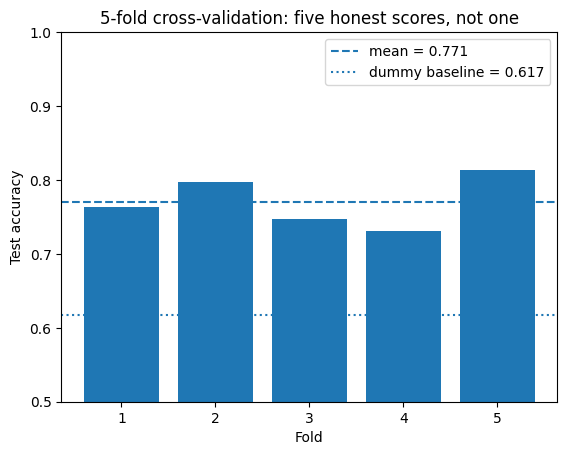

In [5]:
# see the spread!
plt.bar(range(1, 6), fold_accuracies)
plt.axhline(np.mean(fold_accuracies), linestyle='--',
            label='mean = %.3f' % np.mean(fold_accuracies))
plt.axhline(0.617, linestyle=':', label='dummy baseline = 0.617')
plt.ylim(0.5, 1.0)
plt.xlabel('Fold')
plt.ylabel('Test accuracy')
plt.title('5-fold cross-validation: five honest scores, not one')
plt.legend()
plt.show()

💡 THAT spread is the honest answer to "how good is this model?" - not any single number. When you write it up, say **mean ± std** ("about 0.77 ± 0.03"), and note that every fold clears the 62% dummy baseline. If one fold ever dips NEAR the baseline, that's your cue to investigate, not to average it away.

# On Your Own
* **The leakage experiment (do this one!):** move the model-building lines ABOVE the loop so all 5 folds reuse one model. Watch the later folds' accuracies inflate - the model already trained on their test rows. Now you've SEEN data leakage, not just heard about it.
* Bump `n_splits` to 10. Does the mean move? Does the std shrink or grow? (More folds = more training rows each, but smaller test piles.)
* Time both runs. K-fold honesty costs k× the training - budget for it.